# 01 RNN Basics

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Build a simple RNN (or LSTM) and process a **sequence** (e.g. text or time steps)
- Train it on a small sequence task (e.g. sentiment or next-step prediction) and see loss/accuracy
- Understand why we use an RNN instead of a plain feedforward NN for sequences

---

## 🌍 Real life

**Where is this used?** RNNs are used for **text classification**, **time series**, **speech**, and **translation** when **order matters**.

**In this notebook we use** an **RNN** to process a **sequence** (e.g. padded word indices) and produce a single output (e.g. sentiment). We use an **RNN** (instead of a plain NN that sees all tokens at once) **because** **order matters**; the RNN processes step by step and keeps a **hidden state** that carries information forward.

**📌 Covers slide(s):** **17** — RNNs, vanishing/exploding gradients. *Do this notebook after that slide.*

---

**Before starting:** Run the imports cell below.

## Theory (short)

- **RNN:** At each time step t, it takes **input x_t** and **previous hidden state h_{t-1}**, and outputs **new hidden state h_t** (and optionally output y_t). So it maintains **memory** along the sequence.
- **Why sequences?** For text, time series, or any ordered data, the **order** of elements matters; an RNN processes them in order and passes information forward.
- **SimpleRNN vs LSTM:** SimpleRNN can suffer from vanishing gradients on long sequences; LSTM uses gates to control what to remember/forget. We use LSTM here for stability.
- **We use RNN** instead of a plain NN because a plain NN would treat the sequence as a flat bag of inputs and lose order.

## 📥 Inputs & 📤 Outputs

**Inputs:** TensorFlow/Keras, NumPy. We use a small text dataset (e.g. IMDB subset) or a synthetic sequence so the notebook runs in ~10 min.

**Dataset:** Real — IMDB (movie reviews, sentiment).

**Outputs:** Training/validation loss and accuracy (with axis labels), test accuracy, and a short "what you did" summary.

## Step 1: Imports and load a small sequence dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import tensorflow as tf
    from tensorflow import keras
    HAS_TF = True
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    HAS_TF = False

if HAS_TF:
    (x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=2000)
    maxlen = 80
    x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=maxlen, padding="post", truncating="post")
    x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=maxlen, padding="post", truncating="post")
    x_train, y_train = x_train[:2000], y_train[:2000]
    x_test, y_test = x_test[:500], y_test[:500]
    print("Train:", x_train.shape, "Test:", x_test.shape)
else:
    print("Install TensorFlow: pip install tensorflow")

Train: (2000, 80) Test: (500, 80)


## Step 2: Build RNN model (we use LSTM instead of SimpleRNN for better gradient flow on sequences)

In [2]:
if HAS_TF:
    model = keras.Sequential([
        keras.layers.Embedding(2000, 32, input_length=maxlen),
        keras.layers.LSTM(32),
        keras.layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    model.summary()

Model: "sequential"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 embedding (Embedding)       (None, 80, 32)            64000     


 lstm (LSTM)                 (None, 32)                8320      


 dense (Dense)               (None, 1)                 33        


Total params: 72353 (282.63 KB)


Trainable params: 72353 (282.63 KB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


## Step 3: Train (2 epochs so it runs quickly)

In [3]:
if HAS_TF:
    history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=2, batch_size=64, verbose=1)

Epoch 1/2


 1/32 [..............................] - ETA: 12s - loss: 0.6929 - accuracy: 0.4531

 7/32 [=====>........................] - ETA: 0s - loss: 0.6936 - accuracy: 0.4888 

14/32 [============>.................] - ETA: 0s - loss: 0.6937 - accuracy: 0.4922

21/32 [==================>...........] - ETA: 0s - loss: 0.6933 - accuracy: 0.4978

...

 8/32 [======>.......................] - ETA: 0s - loss: 0.6888 - accuracy: 0.5312

15/32 [=============>................] - ETA: 0s - loss: 0.6887 - accuracy: 0.5271

22/32 [===================>..........] - ETA: 0s - loss: 0.6874 - accuracy: 0.5291

29/32 [==========================>...] - ETA: 0s - loss: 0.6857 - accuracy: 0.5420

32/32 [==============================] - 0s 9ms/step - loss: 0.6855 - accuracy: 0.5385 - val_loss: 0.6812 - val_accuracy: 0.5740


## Step 4: Plot loss and accuracy

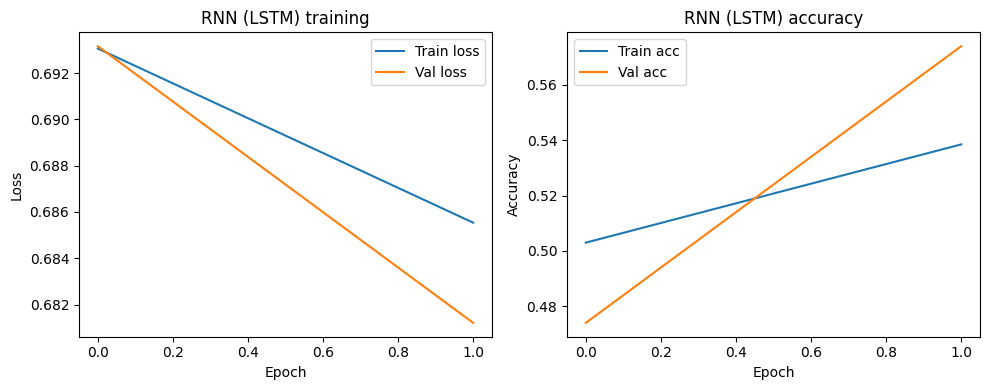

Test accuracy: 0.5740


In [4]:
if HAS_TF:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.plot(history.history["loss"], label="Train loss")
    ax1.plot(history.history["val_loss"], label="Val loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title("RNN (LSTM) training")
    ax1.legend()
    ax2.plot(history.history["accuracy"], label="Train acc")
    ax2.plot(history.history["val_accuracy"], label="Val acc")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_title("RNN (LSTM) accuracy")
    ax2.legend()
    plt.tight_layout()
    plt.show()
    _, acc = model.evaluate(x_test, y_test, verbose=0)
    print("Test accuracy: %.4f" % acc)

## 🧩 Mini-exercise

**Try it (choose one):** Change the number of LSTM units (e.g. 32 → 64) and retrain for 1 epoch. Does loss go down faster? Or reduce the embedding dimension and see how it affects accuracy.

---

## ✅ Summary

**What you did:** Built an RNN (LSTM) for sequence classification (IMDB sentiment), trained it for 2 epochs, and plotted loss/accuracy.

**In real life you'd also:** Use longer sequences, more data, and tune embedding size and LSTM units.

**The main idea:** RNNs process sequences step by step and keep a hidden state; we use them (instead of a plain NN) when **order matters**.

**Next:** `03_lstm_advanced` goes deeper into LSTM/GRU; `04_transformer_attention` introduces attention and transformers.